# Connect Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Is CUDA available? True
GPU Name: NVIDIA L4


# Install **pytorch-tabnet, optuna**

In [ ]:
!pip install pytorch-tabnet optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 38.3 MB/s eta 0:00:00


# Important Libraries

In [ ]:
import optuna
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pytorch_tabnet.metrics import Metric
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pytorch_tabnet.metrics import Metric
import joblib
import os
import gc

# Sentinel-2

## Data Loading

In [ ]:
save_dir = "/content/drive/MyDrive/Thesis/Trained_models/"
file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_with_veg_data.csv"

print("Loading data...")
df = pd.read_csv(file_path)
print("Data is loaded")

print("\nData preparation...")

df1 = df.loc[df["age"] != 5].dropna()

df1.drop(columns=["age", "basal_area", "height", "poly_id", "S2_Date"], axis=1, inplace=True)

y = df1["stock_per_ha"].values
X = df1.drop(columns="stock_per_ha", axis=1).values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

print(f"\nDatasets are read! X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, X_val shape: {X_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! X_train shape: (284286, 52), X_test shape: (50169, 52), X_val shape: (59022, 52)


### Cleaning RAM

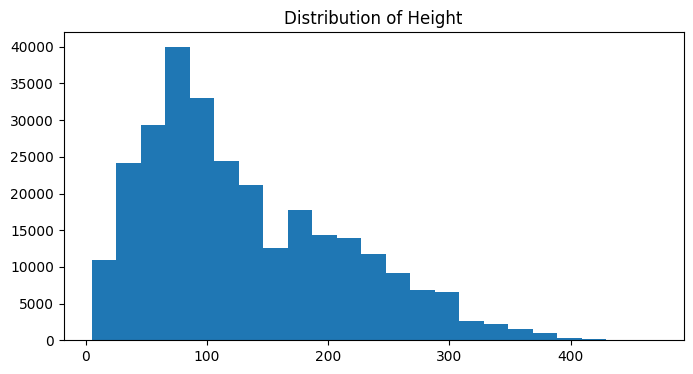

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(y_train, bins = 23)
plt.title("Distribution of Height")
plt.show()

In [ ]:
import gc
del df, df1, X, y

gc.collect()

4293

##Bayesian Optimization

In [ ]:
X_train_np = X_train.values.astype(np.float32) if isinstance(X_train, pd.DataFrame) else X_train.astype(np.float32)
y_train_np = y_train.values.astype(np.float32).reshape(-1, 1) if isinstance(y_train, pd.Series) else y_train.astype(np.float32).reshape(-1, 1)

X_val_np = X_val.values.astype(np.float32) if isinstance(X_val, pd.DataFrame) else X_val.astype(np.float32)
y_val_np = y_val.values.astype(np.float32).reshape(-1, 1) if isinstance(y_val, pd.Series) else y_val.astype(np.float32).reshape(-1, 1)

X_test_np = X_test.values.astype(np.float32) if isinstance(X_test, pd.DataFrame) else X_test.astype(np.float32)
y_test_np = y_test.values.astype(np.float32).reshape(-1, 1) if isinstance(y_test, pd.Series) else y_test.astype(np.float32).reshape(-1, 1)

In [ ]:
def objective_standard_reg(trial):
    # Hyperparameter Space
    n_d = trial.suggest_int('n_d', 16, 64, step=16)
    n_a = n_d # Keep equal
    n_steps = trial.suggest_int('n_steps', 3, 7)
    gamma = trial.suggest_float('gamma', 1.0, 2.0)
    lambda_sparse = trial.suggest_float('lambda_sparse', 1e-5, 1e-2, log=True)
    learning_rate = trial.suggest_float('lr', 1e-3, 1e-1, log=True)

    # Initialize Model
    reg = TabNetRegressor(
        n_d=n_d,
        n_a=n_a,
        n_steps=n_steps,
        gamma=gamma,
        lambda_sparse=lambda_sparse,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=learning_rate),
        scheduler_params={"step_size":20, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax',
        verbose=0,
        device_name='cuda'
    )

    # Train Model (Using all data, passing validation set)
    reg.fit(
        X_train=X_train_np, y_train=y_train_np,
        eval_set=[(X_val_np, y_val_np)],
        eval_name=['valid'],
        eval_metric=['rmse'],
        max_epochs=100,
        patience=20,
        batch_size=4096,
        virtual_batch_size=512,
        num_workers= 12
    )

    # Evaluate
    preds = reg.predict(X_val_np)
    # Clip negatives so the tuner learns that negative predictions are penalized implicitly
    preds = np.clip(preds, 0, None)
    rmse = np.sqrt(mean_squared_error(y_val_np, preds))

    return rmse

print("\nStarting Optuna Optimization for Standard TabNet Height Model...")

study_std = optuna.create_study(direction='minimize')
# 50 trials is usually enough to find a great region!
study_std.optimize(objective_standard_reg, n_trials=50)

print("\nBest Parameters Found:")
for key, value in study_std.best_params.items():
    print(f"  {key}: {value}")

[I 2026-05-09 06:06:55,519] A new study created in memory with name: no-name-f5493f7c-eb7f-4894-938e-b4a6ebff8301



Starting Optuna Optimization for Standard TabNet Height Model...

Early stopping occurred at epoch 82 with best_epoch = 62 and best_valid_rmse = 59.3384


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-09 06:14:32,432] Trial 0 finished with value: 59.33840154939717 and parameters: {'n_d': 32, 'n_steps': 5, 'gamma': 1.1825582853567607, 'lambda_sparse': 0.008100518780220488, 'lr': 0.02885428363485757}. Best is trial 0 with value: 59.33840154939717.



Early stopping occurred at epoch 73 with best_epoch = 53 and best_valid_rmse = 59.26322


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-09 06:21:16,076] Trial 1 finished with value: 59.26322332333835 and parameters: {'n_d': 64, 'n_steps': 5, 'gamma': 1.5094884538341073, 'lambda_sparse': 0.005720470257379055, 'lr': 0.007319934481319934}. Best is trial 1 with value: 59.26322332333835.


...


Early stopping occurred at epoch 81 with best_epoch = 61 and best_valid_rmse = 59.1459


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-09 12:47:54,768] Trial 48 finished with value: 59.1459025881654 and parameters: {'n_d': 64, 'n_steps': 5, 'gamma': 1.6684035560271155, 'lambda_sparse': 0.00024025159293547592, 'lr': 0.009781532819328167}. Best is trial 41 with value: 58.98872086639212.



Early stopping occurred at epoch 69 with best_epoch = 49 and best_valid_rmse = 59.12936


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-09 12:55:23,598] Trial 49 finished with value: 59.129362368798 and parameters: {'n_d': 64, 'n_steps': 6, 'gamma': 1.5746581343368324, 'lambda_sparse': 0.00047696083337250605, 'lr': 0.013322815551639867}. Best is trial 41 with value: 58.98872086639212.



Best Parameters Found:
  n_d: 64
  n_steps: 5
  gamma: 1.7994446317157529
  lambda_sparse: 0.000516096733201913
  lr: 0.00762200595484607


**Best Params**

In [ ]:
# Best Parameters Found:
#   n_d: 64
#   n_steps: 5
#   gamma: 1.7994446317157529
#   lambda_sparse: 0.000516096733201913
#   lr: 0.00762200595484607

# Alpha Earth Foundation + Sentinel-2


## Data Loading

In [ ]:
save_dir = "/content/drive/MyDrive/Thesis/Trained_models/"
file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_aef_with_veg_data.csv"

print("Loading data...")
df = pd.read_csv(file_path)
print("Data is loaded")

print("\nData preparation...")

df1 = df.loc[df["age"] != 5].dropna()

df1.drop(columns=["age", "basal_area", "height", "poly_id", "S2_Date"], axis=1, inplace=True)

y = df1["stock_per_ha"].values
X = df1.drop(columns="stock_per_ha", axis=1).values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

print(f"\nDatasets are read! X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, X_val shape: {X_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! X_train shape: (284117, 308), X_test shape: (50139, 308), X_val shape: (58987, 308)


### Cleaning RAM

In [ ]:
import gc
del df, df1, X, y

gc.collect()

0

## Bayesian Optimization

In [ ]:
X_train_np = X_train.values.astype(np.float32) if isinstance(X_train, pd.DataFrame) else X_train.astype(np.float32)
y_train_np = y_train.values.astype(np.float32).reshape(-1, 1) if isinstance(y_train, pd.Series) else y_train.astype(np.float32).reshape(-1, 1)

X_val_np = X_val.values.astype(np.float32) if isinstance(X_val, pd.DataFrame) else X_val.astype(np.float32)
y_val_np = y_val.values.astype(np.float32).reshape(-1, 1) if isinstance(y_val, pd.Series) else y_val.astype(np.float32).reshape(-1, 1)

X_test_np = X_test.values.astype(np.float32) if isinstance(X_test, pd.DataFrame) else X_test.astype(np.float32)
y_test_np = y_test.values.astype(np.float32).reshape(-1, 1) if isinstance(y_test, pd.Series) else y_test.astype(np.float32).reshape(-1, 1)

In [ ]:
def objective_standard_reg(trial):
    # Hyperparameter Space
    n_d = trial.suggest_int('n_d', 16, 64, step=16)
    n_a = n_d # Keep equal
    n_steps = trial.suggest_int('n_steps', 3, 7)
    gamma = trial.suggest_float('gamma', 1.0, 2.0)
    lambda_sparse = trial.suggest_float('lambda_sparse', 1e-5, 1e-2, log=True)
    learning_rate = trial.suggest_float('lr', 1e-3, 1e-1, log=True)

    # Initialize Model
    reg = TabNetRegressor(
        n_d=n_d,
        n_a=n_a,
        n_steps=n_steps,
        gamma=gamma,
        lambda_sparse=lambda_sparse,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=learning_rate),
        scheduler_params={"step_size":20, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax',
        verbose=0,
        device_name='cuda'
    )

    # Train Model (Using all data, passing validation set)
    reg.fit(
        X_train=X_train_np, y_train=y_train_np,
        eval_set=[(X_val_np, y_val_np)],
        eval_name=['valid'],
        eval_metric=['rmse'],
        max_epochs=100,
        patience=20,
        batch_size=4096,
        virtual_batch_size=512,
        num_workers= 12
    )

    # Evaluate
    preds = reg.predict(X_val_np)
    rmse = np.sqrt(mean_squared_error(y_val_np, preds))

    return rmse

print("\nStarting Optuna Optimization for Standard TabNet Height Model...")

study_std = optuna.create_study(direction='minimize')
# 50 trials is usually enough to find a great region!
study_std.optimize(objective_standard_reg, n_trials=50)

print("\nBest Parameters Found:")
for key, value in study_std.best_params.items():
    print(f"  {key}: {value}")

[I 2026-05-09 16:44:48,463] A new study created in memory with name: no-name-826837e5-25c7-4416-9f1d-4578b1101b60



Starting Optuna Optimization for Standard TabNet Height Model...
Stop training because you reached max_epochs = 100 with best_epoch = 99 and best_valid_rmse = 47.35521


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-09 16:58:34,048] Trial 0 finished with value: 47.35520952483079 and parameters: {'n_d': 32, 'n_steps': 7, 'gamma': 1.3227008201980706, 'lambda_sparse': 2.4196940137973896e-05, 'lr': 0.003820196002403841}. Best is trial 0 with value: 47.35520952483079.


Stop training because you reached max_epochs = 100 with best_epoch = 97 and best_valid_rmse = 27.96017


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-09 17:08:12,735] Trial 1 finished with value: 27.96017348425312 and parameters: {'n_d': 64, 'n_steps': 4, 'gamma': 1.3170362495449723, 'lambda_sparse': 0.00198551219516612, 'lr': 0.0035805097869640195}. Best is trial 1 with value: 27.96017348425312.


...

Stop training because you reached max_epochs = 100 with best_epoch = 96 and best_valid_rmse = 30.0081


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-10 00:40:50,714] Trial 48 finished with value: 30.008096238244605 and parameters: {'n_d': 48, 'n_steps': 3, 'gamma': 1.0129020749685134, 'lambda_sparse': 2.0266774231078817e-05, 'lr': 0.004719361791769798}. Best is trial 27 with value: 24.209982031808053.


Stop training because you reached max_epochs = 100 with best_epoch = 95 and best_valid_rmse = 24.21073


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-10 00:48:26,647] Trial 49 finished with value: 24.210726997713483 and parameters: {'n_d': 64, 'n_steps': 3, 'gamma': 1.0049033561290102, 'lambda_sparse': 5.882851120489276e-05, 'lr': 0.011003400851157353}. Best is trial 27 with value: 24.209982031808053.



Best Parameters Found:
  n_d: 64
  n_steps: 4
  gamma: 1.0094621060357858
  lambda_sparse: 2.317311523727845e-05
  lr: 0.008578113555072568


**Best Params**

In [ ]:
# Best Parameters Found:
#   n_d: 64
#   n_steps: 4
#   gamma: 1.0094621060357858
#   lambda_sparse: 2.317311523727845e-05
#   lr: 0.008578113555072568